In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pywt
from skimage import data
from skimage.transform import resize
from skimage import data, metrics
from skimage.util import random_noise

## Haar小波轉換

1D

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def haar_1d(signal):
    n = len(signal)
    half = n // 2 #分給低頻與高頻

    # 低頻：相鄰元素的平均
    low = np.zeros(half)
    # 高頻：相鄰元素的差異
    high = np.zeros(half)

    for i in range(half):
        low[i] = (signal[2*i] + signal[2*i+1]) / 2
        high[i] = (signal[2*i] - signal[2*i+1]) / 2

    return low, high

# 測試一維小波
signal = np.array([10, 12, 8, 6, 14, 16, 4, 2])
print("原始訊號:", signal)

low, high = haar_1d(signal)
print("低頻部分:", low)
print("高頻部分:", high)

原始訊號: [10 12  8  6 14 16  4  2]
低頻部分: [11.  7. 15.  3.]
高頻部分: [-1.  1. -1.  1.]


2D

原始圖像:


/tmp/ipython-input-3711652149.py:14: RuntimeWarning: overflow encountered in scalar add
  low[i] = (signal[2*i] + signal[2*i+1]) / 2
/tmp/ipython-input-3711652149.py:15: RuntimeWarning: overflow encountered in scalar subtract
  high[i] = (signal[2*i] - signal[2*i+1]) / 2



小波轉換結果:


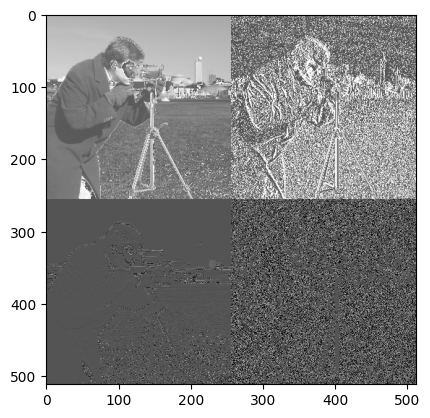

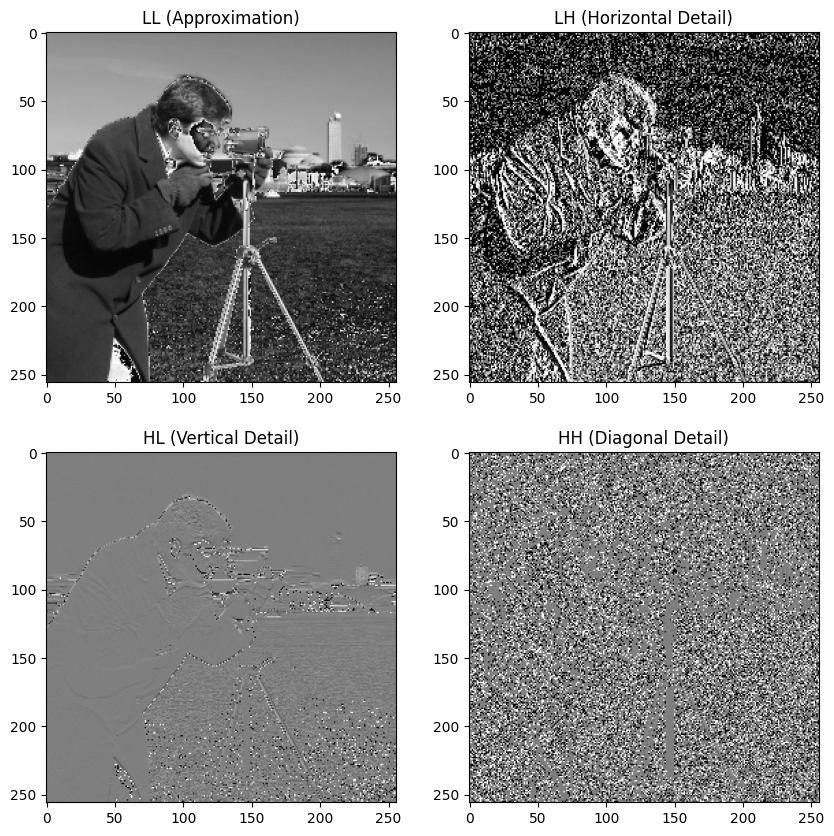

In [4]:
from IPython.testing import test
def haar_2d(image):
    rows, cols = image.shape
    temp = np.zeros_like(image, dtype=float)
    result = np.zeros_like(image, dtype=float)

    # 步驟1：對每一行做小波轉換
    for i in range(rows):
        low, high = haar_1d(image[i, :])
        temp[i, :cols//2] = low
        temp[i, cols//2:] = high

    # 步驟2：對每一列做小波轉換
    for j in range(cols):
        low, high = haar_1d(temp[:, j])
        result[:rows//2, j] = low
        result[rows//2:, j] = high

    return result

test_image = data.camera()

print("原始圖像:")
plt.imshow(test_image, cmap='gray')

# 執行二維小波轉換
wavelet_result = haar_2d(test_image)
wavelet_result = cv2.normalize(wavelet_result, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
print("\n小波轉換結果:")
plt.imshow(wavelet_result, cmap='gray')


rows, cols = wavelet_result.shape
mid_row, mid_col = rows // 2, cols // 2
LL = wavelet_result[:mid_row, :mid_col] # 左上：近似圖
LH = wavelet_result[:mid_row, mid_col:] # 右上：水平邊緣
HL = wavelet_result[mid_row:, :mid_col] # 左下：垂直邊緣
HH = wavelet_result[mid_row:, mid_col:] # 右下：對角邊緣


plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1); plt.imshow(LL, cmap='gray'); plt.title("LL (Approximation)")
plt.subplot(2, 2, 2); plt.imshow(LH, cmap='gray'); plt.title("LH (Horizontal Detail)")
plt.subplot(2, 2, 3); plt.imshow(HL, cmap='gray'); plt.title("HL (Vertical Detail)")
plt.subplot(2, 2, 4); plt.imshow(HH, cmap='gray'); plt.title("HH (Diagonal Detail)")
plt.show()

## db4

原始影像尺寸: (256, 256)
1. 開始處理每一行 (Row Processing)...
2. 開始處理每一列 (Column Processing)...
分解完成！
子頻帶尺寸: LL=(128, 128), LH=(128, 128)


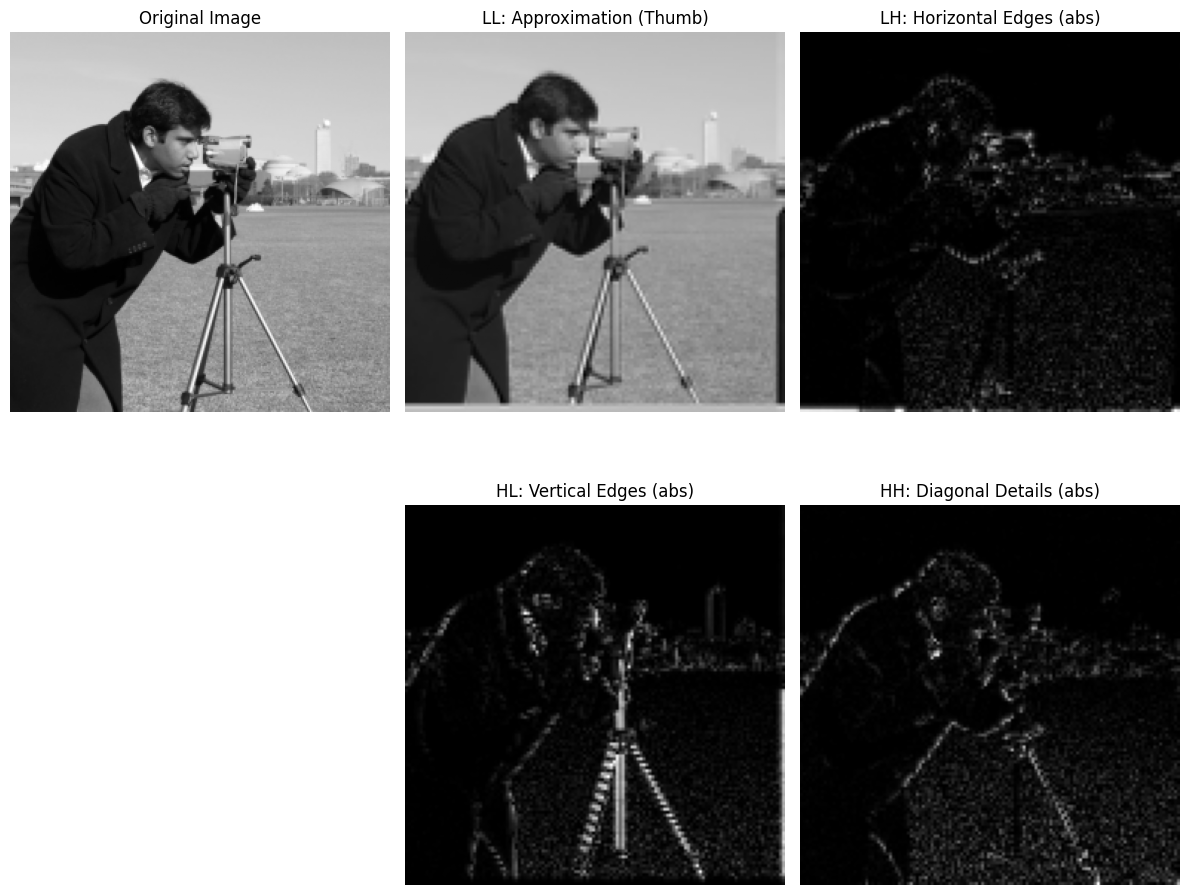

In [5]:
def manual_db4_decomposition_1d(signal):
    #h:低通濾波器係數
    h = np.array([
        -0.010597401785069,
        0.032883011666885,
        0.030841381835561,
        -0.187034811719092,
        -0.027983769416859,
        0.630880767929859,
        0.714846570552915,
        0.230377813308896
    ])

    #g:高通分解濾波器
    g = np.array([
        -0.230377813308896,
        0.714846570552915,
        -0.630880767929859,
        -0.027983769416859,
        0.187034811719092,
        0.030841381835561,
        -0.032883011666885,
        -0.010597401785069
    ])

    N = len(signal)
    filter_len = len(h)
    # 簡單的邊界處理：假設輸入長度是偶數，使用循環補零模擬
    # 防止濾波器超過訊號長
    padded_signal = np.pad(signal, (0, filter_len-1), mode='wrap')

    output_len = N // 2
    cA = np.zeros(output_len) # ca:近似與低頻
    cD = np.zeros(output_len) # cd:細節與高頻

    # 滑動視窗 + 內積運算
    for i in range(output_len):
        start_idx = 2 * i #downsampling，輸出長度變成一半
        segment = padded_signal[start_idx : start_idx + filter_len]
        cA[i] = np.dot(segment, h)
        cD[i] = np.dot(segment, g)

    return cA, cD


def manual_db4_2d(image):
    rows, cols = image.shape #假設256*256

    # 確保維度是偶數 (為了簡化手寫示範)
    if rows % 2 != 0 or cols % 2 != 0:
        raise ValueError("請確保影像長寬皆為偶數。")

    print("1. 開始處理每一行 (Row Processing)...")
    # 準備中間緩衝區：寬度變一半
    temp_L = np.zeros((rows, cols // 2)) # 存放水平低頻
    temp_H = np.zeros((rows, cols // 2)) # 存放水平高頻

    # 開始做行方向的處理
    for r in range(rows):
        # 取出第 r 行
        row_signal = image[r, :]
        # 執行 1D 分解
        cA_row, cD_row = manual_db4_decomposition_1d(row_signal)
        # 存回緩存區
        temp_L[r, :] = cA_row #存入低頻 (256*128)
        temp_H[r, :] = cD_row #存入高頻 (256*128)

    print("2. 開始處理每一列 (Column Processing)...")
    out_rows, out_cols = rows // 2, cols // 2

    #建立output LL,LH,HL,HH
    LL = np.zeros((out_rows, out_cols)) #(128*128)
    LH = np.zeros((out_rows, out_cols))
    HL = np.zeros((out_rows, out_cols))
    HH = np.zeros((out_rows, out_cols))

    for c in range(out_cols):

        col_signal_L = temp_L[:, c] #低頻暫存
        cA_col, cD_col = manual_db4_decomposition_1d(col_signal_L)
        LL[:, c] = cA_col # Row Low -> Col Low#(128*128)
        LH[:, c] = cD_col # Row Low -> Col High#(128*128)

        col_signal_H = temp_H[:, c] #高頻暫存
        cA_col_H, cD_col_H = manual_db4_decomposition_1d(col_signal_H)
        HL[:, c] = cA_col_H # Row High -> Col Low#(128*128)
        HH[:, c] = cD_col_H # Row High -> Col High#(128*128)

    return LL, LH, HL, HH


# 載入範例圖片 (攝影師)
original_image = data.camera()
original_image = resize(original_image, (256, 256), anti_aliasing=True)

# 轉為浮點數
original_image = original_image.astype(float)

print(f"原始影像尺寸: {original_image.shape}")

# --- 執行手動 2D db4 分解 ---
LL_db4, LH_db4, HL_db4, HH_db4 = manual_db4_2d(original_image)

print("分解完成！")
print(f"子頻帶尺寸: LL={LL_db4.shape}, LH={LH_db4.shape}")



def enhance_detail(coeffs):
    # 取絕對值並乘以一個係數來增強顯示效果
    return np.abs(coeffs) * 2.0

plt.figure(figsize=(12, 10))

# 顯示原始影像
plt.subplot(2, 3, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# 顯示四個子頻帶 (標準排列方式)
# LL (左上)
plt.subplot(2, 3, 2)
plt.imshow(LL_db4, cmap='gray')
plt.title('LL: Approximation (Thumb)')
plt.axis('off')

# LH (右上) - 水平邊緣
plt.subplot(2, 3, 3)
# 注意：這裡對細節取了絕對值以便觀看
plt.imshow(enhance_detail(LH_db4), cmap='gray', vmin=0)
plt.title('LH: Horizontal Edges (abs)')
plt.axis('off')

# HL (左下) - 垂直邊緣
plt.subplot(2, 3, 5)
plt.imshow(enhance_detail(HL_db4), cmap='gray', vmin=0)
plt.title('HL: Vertical Edges (abs)')
plt.axis('off')

# HH (右下) - 對角細節
plt.subplot(2, 3, 6)
plt.imshow(enhance_detail(HH_db4), cmap='gray', vmin=0)
plt.title('HH: Diagonal Details (abs)')
plt.axis('off')

plt.tight_layout()
plt.show()

## 影像去躁

含噪影像 PSNR: 26.17 dB
Haar 去噪 PSNR: 26.63 dB
db4  去噪 PSNR: 27.54 dB


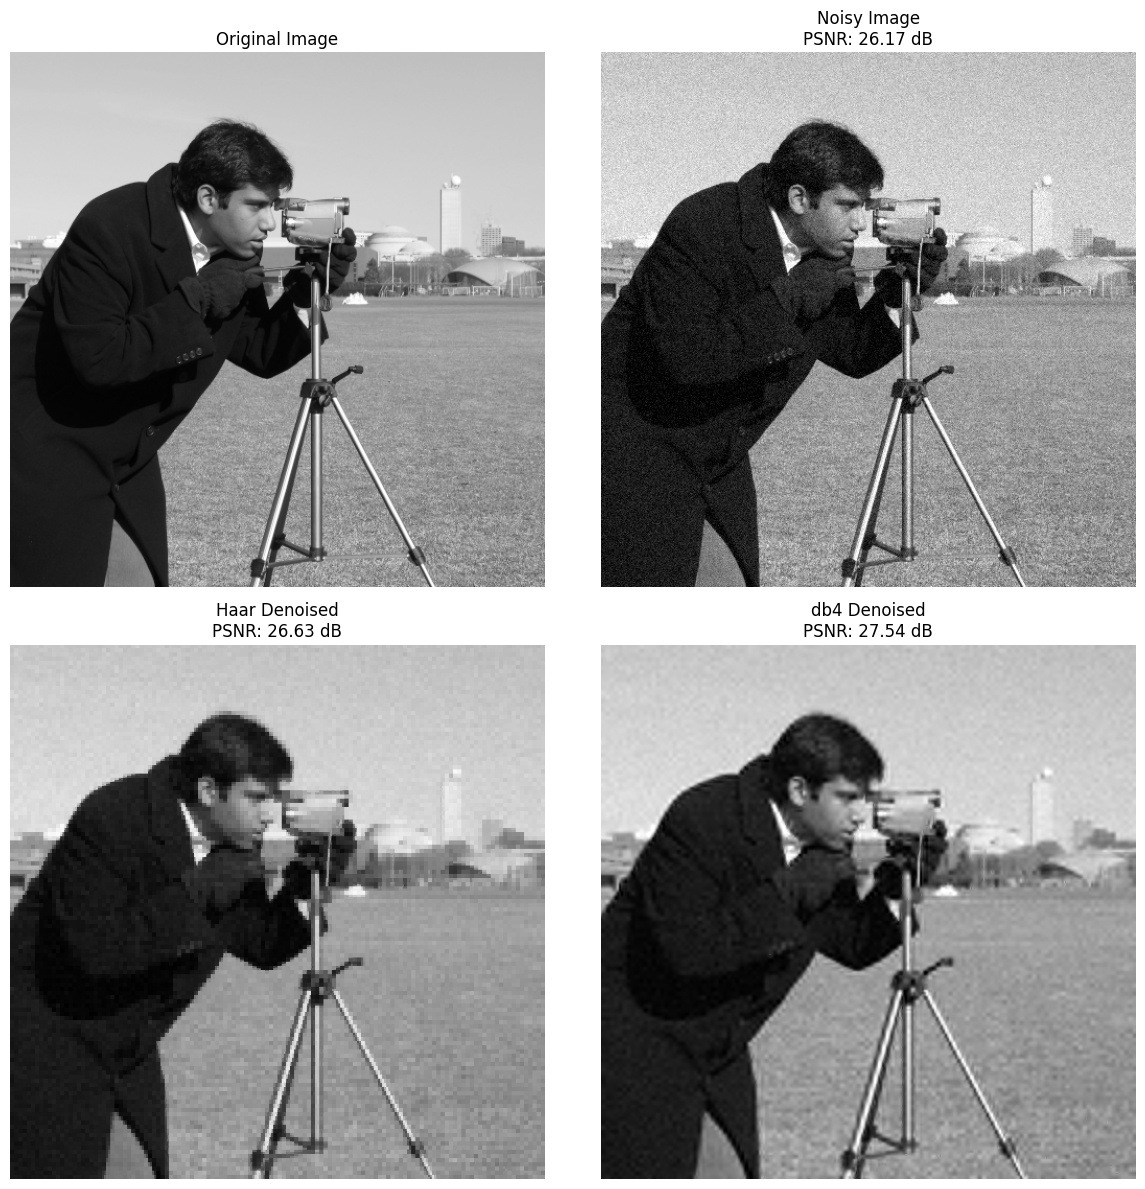

In [6]:
import numpy as np
import pywt
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.util import random_noise

def wavelet_denoising(image, wavelet_name, level=2):
    # 1. 小波分解 (Decomposition)
    coeffs = pywt.wavedec2(image, wavelet_name, level=level)

    # 2. 計算閾值 (Universal Threshold)
    # 我們利用最底層的對角細節 (HH) 來估計噪聲強度 sigma
    # 這是標準的 Donoho-Johnstone 方法
    cAH_last = coeffs[-1][2] # 取最後一層的 HH
    sigma = np.median(np.abs(cAH_last)) / 0.6745

    # 計算通用閾值 T = sigma * sqrt(2 * log(N))
    threshold = sigma * np.sqrt(2 * np.log(image.size))

    # 3. 閾值處理 (Thresholding)
    # 注意：我們通常不對近似係數 (LL, coeffs[0]) 做處理，只處理細節係數
    new_coeffs = list(coeffs) # 複製一份

    for i in range(1, len(coeffs)): # 從第1層細節開始，跳過第0層近似
        # coeffs[i] 包含 (LH, HL, HH)
        new_coeffs[i] = tuple([
            pywt.threshold(c, threshold, mode='soft') for c in coeffs[i]
        ])

    # 4. 小波重建 (Reconstruction)
    denoised_image = pywt.waverec2(new_coeffs, wavelet_name)

    # 確保數值在 0~1 之間 (避免溢位)
    denoised_image = np.clip(denoised_image, 0, 1)

    return denoised_image

# 1. 準備數據
original = img_as_float(data.camera())
sigma_noise = 0.05
noisy = random_noise(original, var=sigma_noise**2)

# 2. 執行去噪
denoised_haar = wavelet_denoising(noisy, 'haar')
# db4
denoised_db4 = wavelet_denoising(noisy, 'db4')

# 3. 計算指標 (PSNR - 越高越好)
psnr_noisy = psnr(original, noisy)
psnr_haar = psnr(original, denoised_haar)
psnr_db4 = psnr(original, denoised_db4)

print(f"含噪影像 PSNR: {psnr_noisy:.2f} dB")
print(f"Haar 去噪 PSNR: {psnr_haar:.2f} dB")
print(f"db4  去噪 PSNR: {psnr_db4:.2f} dB")

# 4. 視覺化比較 (Zoom in 看細節)
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# 顯示全圖
axes[0, 0].imshow(original, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(noisy, cmap='gray')
axes[0, 1].set_title(f'Noisy Image\nPSNR: {psnr_noisy:.2f} dB')
axes[0, 1].axis('off')

axes[1, 0].imshow(denoised_haar, cmap='gray')
axes[1, 0].set_title(f'Haar Denoised\nPSNR: {psnr_haar:.2f} dB')
axes[1, 0].axis('off')

axes[1, 1].imshow(denoised_db4, cmap='gray')
axes[1, 1].set_title(f'db4 Denoised\nPSNR: {psnr_db4:.2f} dB')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


## 影像壓縮

原始影像檔案 (original_raw.npy): 2048.12 KB
--------------------------------------------------------------------------------
保留比例       | 檔案大小 (KB)       | 壓縮比 (File)      | PSNR (dB) 
--------------------------------------------------------------------------------
    50.0% |       1164.62 KB |          1.76x |     56.17
    10.0% |        330.82 KB |          6.19x |     34.44
     5.0% |        215.92 KB |          9.49x |     30.93
     1.0% |        113.31 KB |         18.08x |     13.77


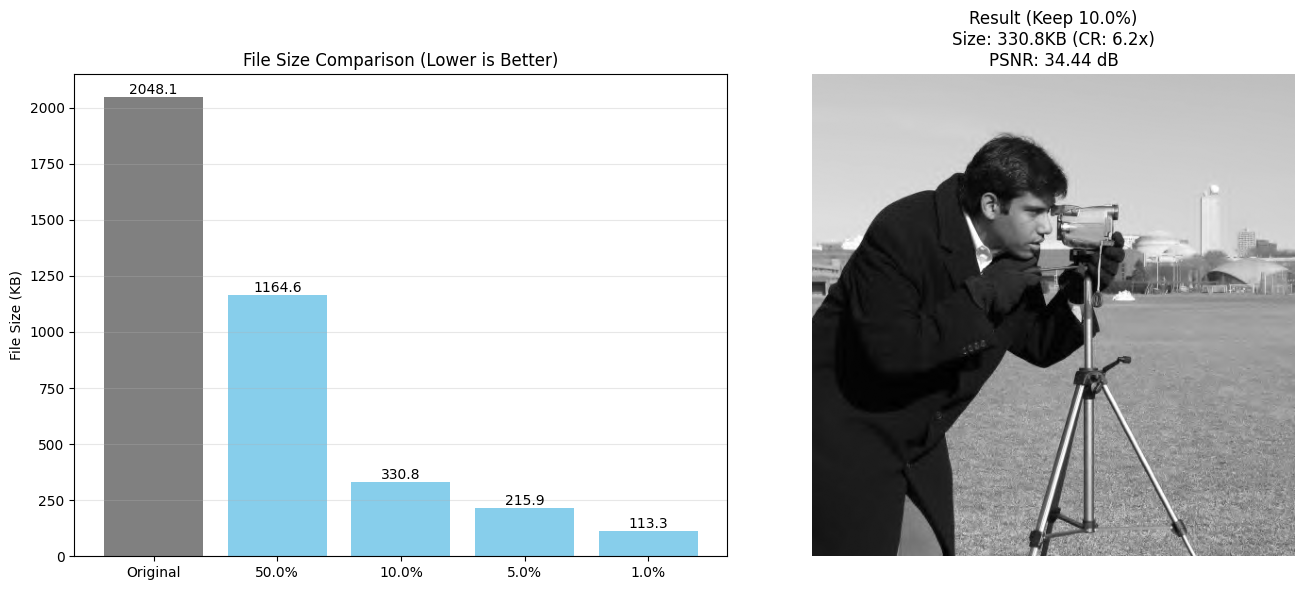

In [7]:
import os
from skimage import data, img_as_float
from skimage.metrics import peak_signal_noise_ratio as psnr

def save_and_measure(image, wavelet='db4', level=3, keep_ratio=0.1, filename_prefix="test"):

    # --- 1. 小波分解 ---
    coeffs = pywt.wavedec2(image, wavelet, level=level)
    coeff_arr, coeff_slices = pywt.coeffs_to_array(coeffs)

    # --- 2. 閾值處理 (製造 0) ---
    sorted_coeffs = np.sort(np.abs(coeff_arr.ravel()))
    thresh_index = int(len(sorted_coeffs) * (1 - keep_ratio))

    # 邊界保護：如果 keep_ratio 是 1.0，index 可能溢位
    if thresh_index >= len(sorted_coeffs):
        threshold = 0
    else:
        threshold = sorted_coeffs[thresh_index]

    # 硬閾值處理
    coeff_arr_sparse = coeff_arr * (np.abs(coeff_arr) > threshold)

    # --- 3. 儲存檔案 (關鍵修正) ---
    compressed_filename = f"{filename_prefix}_ratio_{keep_ratio}.npz"

    slices_array = np.array(coeff_slices, dtype=object)

    np.savez_compressed(
        compressed_filename,
        coeffs=coeff_arr_sparse,
        slices=slices_array, # 傳入處理過的 array
        shape=image.shape
    )

    # 取得壓縮檔案大小 (Bytes)
    compressed_size = os.path.getsize(compressed_filename)

    # --- 4. 重建影像 ---
    # 讀取時，如果使用了 dtype=object，PyWavelets 通常能直接處理，或者我們需要轉回 list
    # 但在這裡我們直接用記憶體中的 coeff_slices 重建即可，目的是算 PSNR
    coeffs_rec = pywt.array_to_coeffs(coeff_arr_sparse, coeff_slices, output_format='wavedec2')
    rec_img = pywt.waverec2(coeffs_rec, wavelet)
    rec_img = np.clip(rec_img, 0, 1)

    current_psnr = psnr(image, rec_img, data_range=1.0)

    return compressed_filename, compressed_size, rec_img, current_psnr


# 1. 準備影像
original = img_as_float(data.camera())

# 2. 儲存原始影像
original_filename = "original_raw.npy"
np.save(original_filename, original)
original_size = os.path.getsize(original_filename)

print(f"原始影像檔案 ({original_filename}): {original_size / 1024:.2f} KB")
print("-" * 80)
print(f"{'保留比例':<10} | {'檔案大小 (KB)':<15} | {'壓縮比 (File)':<15} | {'PSNR (dB)':<10}")
print("-" * 80)

# 3. 測試
ratios = [0.5, 0.1, 0.05, 0.01]
results = []

for ratio in ratios:
    # 呼叫修正後的函式
    fname, size, rec_img, score = save_and_measure(
        original, 'db4', level=3, keep_ratio=ratio
    )

    file_cr = original_size / size
    print(f"{ratio*100:>8.1f}% | {size/1024:>13.2f} KB | {file_cr:>13.2f}x | {score:>9.2f}")
    results.append((ratio, rec_img, size, score))

# (繪圖部分程式碼與之前相同，可以繼續使用)
plt.figure(figsize=(14, 6))

# 左圖：檔案大小長條圖
ratios_str = [f"{r*100}%" for r in ratios]
sizes_kb = [res[2]/1024 for res in results]
original_kb = original_size / 1024

plt.subplot(1, 2, 1)
bars = plt.bar(['Original'] + ratios_str, [original_kb] + sizes_kb, color=['gray'] + ['skyblue']*len(ratios))
plt.ylabel('File Size (KB)')
plt.title('File Size Comparison (Lower is Better)')
plt.grid(axis='y', alpha=0.3)

# 在長條圖上標示數值
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.1f}', ha='center', va='bottom')

# 右圖：影像品質比較
plt.subplot(1, 2, 2)
# 顯示 10% (通常是甜蜜點) 的結果
target_idx = 1 # 對應 0.1
img_show = results[target_idx][1]
psnr_show = results[target_idx][3]
ratio_show = results[target_idx][0]
file_cr_show = original_size / results[target_idx][2]

plt.imshow(img_show, cmap='gray')
plt.title(f'Result (Keep {ratio_show*100}%)\nSize: {sizes_kb[target_idx]:.1f}KB (CR: {file_cr_show:.1f}x)\nPSNR: {psnr_show:.2f} dB')
plt.axis('off')

plt.tight_layout()
plt.show()

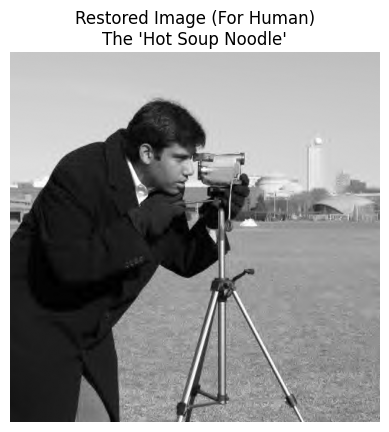

In [13]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

def verify_reconstruction(filename):
    try:
        data = np.load(filename, allow_pickle=True)
        coeffs_sparse = data['coeffs']
        slices = data['slices']
        original_shape = data['shape']
    except FileNotFoundError:
        print("找不到檔案！")
        return

    # 把稀疏的係數轉回原本的結構
    coeffs_rec = pywt.array_to_coeffs(coeffs_sparse, slices, output_format='wavedec2')
    # 重建影像
    restored_image = pywt.waverec2(coeffs_rec, 'db4')

    # 修正數值範圍
    restored_image = np.clip(restored_image, 0, 1)

    plt.imshow(restored_image, cmap='gray')
    plt.title("Restored Image (For Human)\nThe 'Hot Soup Noodle'")
    plt.axis('off')

    plt.show()
verify_reconstruction("test_ratio_0.05.npz")